In [65]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.stats as sms
import statsmodels.api as sm

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AffinityPropagation, MeanShift, DBSCAN, HDBSCAN, OPTICS, Birch
from sklearn import set_config
set_config(transform_output="pandas")

In [2]:
base = pio.templates["simple_white"]
custom_template = base.layout.template

custom_template.layout.update(
    margin=dict(l=50, r=50, t=20, b=50),
    xaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    yaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    colorscale=dict(
        sequential=px.colors.sequential.Inferno,
        diverging=px.colors.diverging.curl_r
    ),
    colorway=px.colors.qualitative.T10
)

pio.templates["tight"] = custom_template
pio.templates.default = "tight"

In [3]:
kc = pd.read_csv('kc_house_data.csv')

kc['date'] = pd.to_datetime(kc.date)

sqft_to_sqmeters = 0.09290303997

kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float,
                'yr_renovated': float, 'yr_built': float,
                'bedrooms': float, 'waterfront': float,
                'view': float, 'condition': float, 'grade': float})

kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan

In [4]:
kc_log = kc.copy()
kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']] = \
np.log10(kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']])

In [5]:
kc_log.yr_renovated = kc_log.yr_renovated.fillna(kc_log.yr_built)
kc_log.loc[:,'sqm_basement'] = kc_log.loc[:,'sqm_basement'].fillna(0)
kc.yr_renovated = kc.yr_renovated.fillna(kc.yr_built)
kc.loc[:,'sqm_basement'] = kc.loc[:,'sqm_basement'].fillna(0)

In [6]:
kc_z=kc.copy()
kc_log_z=kc_log.copy()
for col in kc_z.drop(columns=['id', 'date']).columns:
    kc_z.loc[:,col] = st.zscore(kc_z.loc[:,col])
    kc_log_z.loc[:,col] = st.zscore(kc_log_z.loc[:,col])

In [7]:
kc_pca = kc_z.drop(columns=['id', 'date', 'price', 'lat', 'long']).copy()
kc_log_pca = kc_log_z.drop(columns=['id', 'date', 'price', 'lat', 'long']).copy()

##### K-Means clustering

In [40]:
kmeans = KMeans(n_clusters = 1, init = 'k-means++', max_iter = 300, n_init = 1, random_state = 42)

In [9]:
kmeans_df = pd.DataFrame(data=0.0, columns=range(1, 16), index=['n_clusters','inertia', 'silhouette'])
for i in range(1,16):
    kmeans.n_clusters = i
    kmeans.fit(kc_log_pca)
    kmeans_df.loc['n_clusters', i] = i
    kmeans_df.loc['inertia', i] = kmeans.inertia_ # Sum of squared distances of samples to closest cluster center
    if(i>1):
        kmeans_df.loc['silhouette', i] = silhouette_score(kc_log_pca, kmeans.labels_)
    else:
        kmeans_df.loc['silhouette', i] = 0
kmeans_df

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
n_clusters,1.0,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,15.000000
inertia,324195.0,245786.345489,215712.158447,191801.229235,180087.849224,158638.928581,150138.267779,138333.764209,130949.743095,123564.415095,119725.777555,116671.154293,112781.179207,111165.127289,108494.765864
silhouette,0.0,0.242931,0.198734,0.206878,0.202183,0.200601,0.197608,0.208440,0.199219,0.194212,0.176203,0.176011,0.168163,0.166221,0.167275


In [10]:
px.line(kmeans_df.T, x='n_clusters', y='inertia', width=750, height=200)

In [11]:
px.line(kmeans_df.T, x='n_clusters', y='silhouette', width=750, height=200)

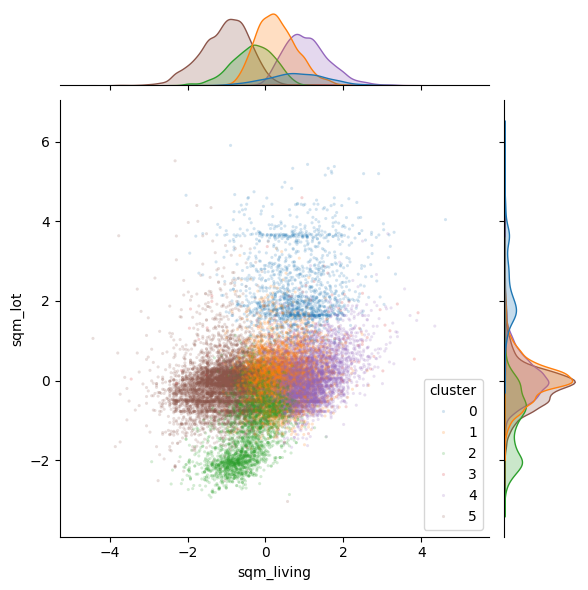

In [12]:
kmeans.n_clusters = 6
kmeans.fit(kc_log_pca)
cluster_df = kc_log_pca
cluster_df['cluster'] = kmeans.labels_
sns.jointplot(cluster_df, x='sqm_living', y='sqm_lot', hue='cluster', palette='tab10', s=5, lw=0, alpha=0.2)

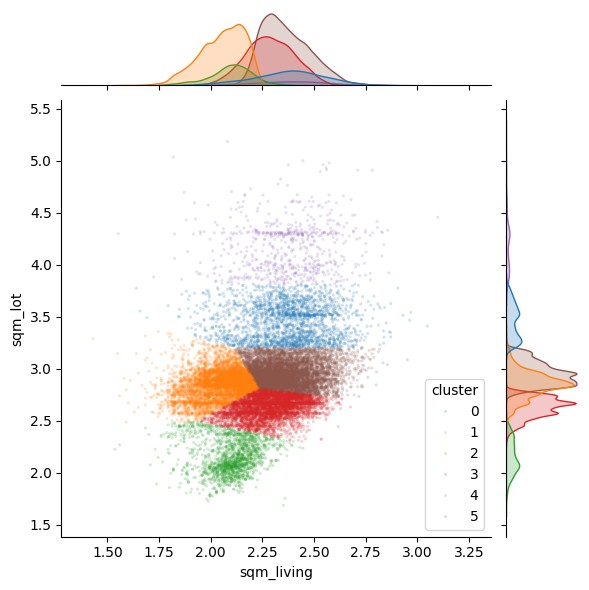

In [41]:
kmeans.n_clusters = 6
kmeans.fit(kc_log[['sqm_living', 'sqm_lot']])
cluster_df = kc_log[['sqm_living', 'sqm_lot']].copy()
cluster_df['cluster'] = kmeans.labels_
sns.jointplot(cluster_df, x='sqm_living', y='sqm_lot', hue='cluster', palette='tab10', s=5, lw=0, alpha=0.2)

<Axes: xlabel='sqm_lot', ylabel='Count'>

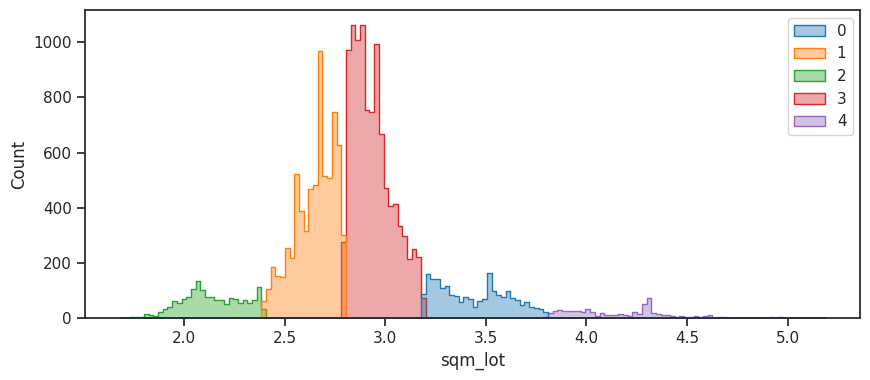

In [14]:
kmeans.n_clusters = 5
kmeans.fit(kc_log.sqm_lot.values.reshape(-1, 1))
cluster_df = kc_log[['sqm_living', 'sqm_lot']].copy()
cluster_df['cluster'] = kmeans.labels_
sns.set(rc={"figure.figsize":(10,4)})
sns.set_style('ticks')
sns.histplot(cluster_df, x='sqm_lot', hue=kmeans.labels_, palette='tab10',
             multiple='layer', element='step', alpha=0.4, linewidth=1)

In [16]:
# ap = AffinityPropagation(random_state=0)
# ap.fit(kc_log.loc[:200,['sqm_living', 'sqm_lot']])
# cluster_df = kc_log.loc[:200,['sqm_living', 'sqm_lot']].copy()
# cluster_df['cluster'] = ap.labels_
# sns.jointplot(cluster_df, x='sqm_living', y='sqm_lot', hue='cluster', palette='tab10', s=5, lw=0, alpha=0.2)

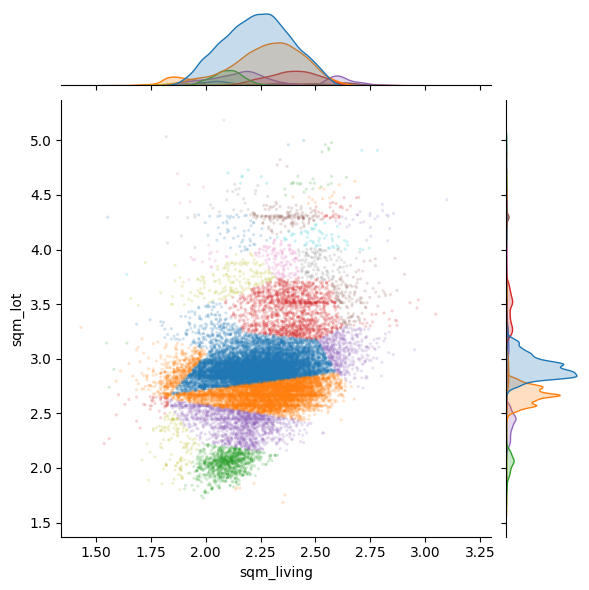

In [36]:
ms = MeanShift(bandwidth=0.1, bin_seeding=True, cluster_all=True)
ms.fit(kc_log.loc[:,['sqm_living', 'sqm_lot']])
cluster_df = kc_log.loc[:,['sqm_living', 'sqm_lot']].copy()
cluster_df['cluster'] = ms.labels_
sns.jointplot(cluster_df, x='sqm_living', y='sqm_lot', hue='cluster', palette='tab10', s=5, lw=0, alpha=0.2, legend=False)

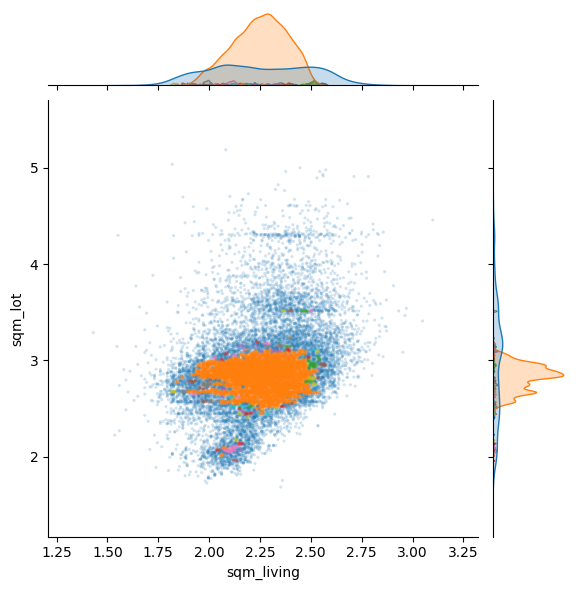

In [63]:
dbscan = DBSCAN(eps=0.01, min_samples=10, algorithm='kd_tree', leaf_size=5000)
dbscan.fit(kc_log.loc[:,['sqm_living', 'sqm_lot']])
cluster_df = kc_log.loc[:,['sqm_living', 'sqm_lot']].copy()
cluster_df['cluster'] = dbscan.labels_
sns.jointplot(cluster_df, x='sqm_living', y='sqm_lot', hue='cluster', palette='tab10', s=5, lw=0, alpha=0.2, legend=False)

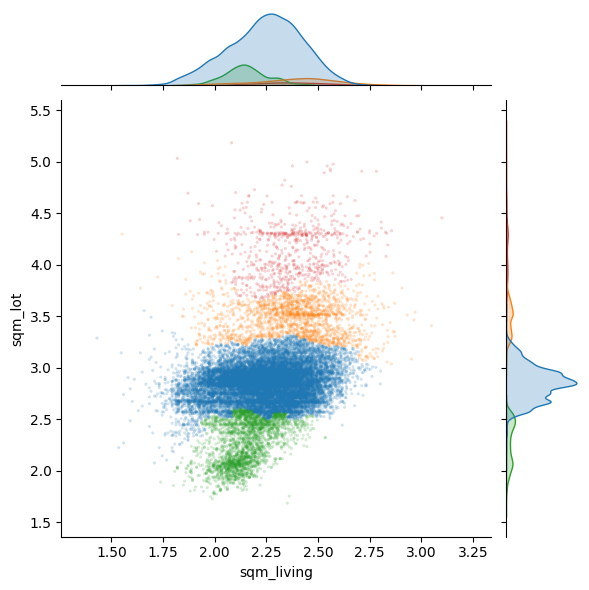

In [73]:
birch = Birch(n_clusters=4, threshold=0.01, branching_factor=50)
birch.fit(kc_log.loc[:,['sqm_living', 'sqm_lot']])
cluster_df = kc_log.loc[:,['sqm_living', 'sqm_lot']].copy()
cluster_df['cluster'] = birch.labels_
sns.jointplot(cluster_df, x='sqm_living', y='sqm_lot', hue='cluster', palette='tab10', s=5, lw=0, alpha=0.2, legend=False)

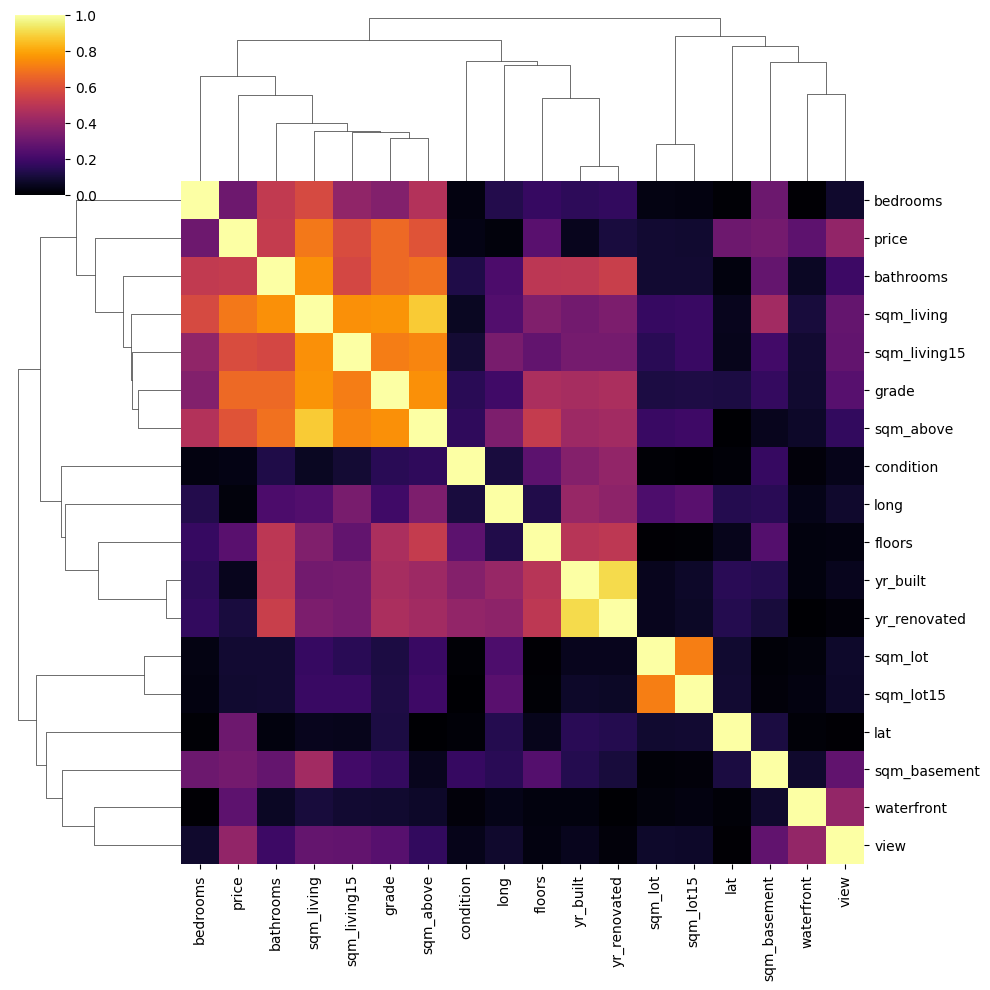

In [37]:
sns.clustermap(kc.loc[:,'price':].corr().abs(), vmin=0, vmax=1, cmap='inferno')

In [15]:
pca = PCA()
pca.fit(kc_pca)
log_pca = PCA()
log_pca.fit(kc_log_pca)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [16]:
px.line(x=range(1, len(pca.explained_variance_ratio_) + 1),
        y=[pca.explained_variance_ratio_.round(2)*100,
        pca.explained_variance_ratio_.round(2).cumsum()*100], markers=True)

In [17]:
px.line(x=range(1, len(log_pca.explained_variance_ratio_) + 1),
        y=[log_pca.explained_variance_ratio_.round(2)*100,
        log_pca.explained_variance_ratio_.round(2).cumsum()*100], markers=True)

In [18]:
pca3 = PCA(3).fit(kc_pca)
pca15 = PCA(15).fit(kc_pca)
log_pca3 = PCA(3).fit(kc_log_pca)
log_pca15 = PCA(15).fit(kc_log_pca)

In [19]:
px.imshow(pd.DataFrame(np.round(pca3.components_, 3), columns=list(kc_pca.columns)),
          text_auto=True, color_continuous_scale=px.colors.diverging.Picnic_r,
          color_continuous_midpoint=0)

In [20]:
px.imshow(pd.DataFrame(np.round(log_pca3.components_, 2), columns=list(kc_log_pca.columns)),
          text_auto=True, color_continuous_scale=px.colors.diverging.Picnic_r,
          color_continuous_midpoint=0)

In [21]:
px.imshow(pd.DataFrame(np.round(pca15.components_, 3), columns=list(kc_pca.columns)),
          text_auto=True, color_continuous_scale=px.colors.diverging.Picnic_r,
          color_continuous_midpoint=0)

In [22]:
kc_pca.cov() # same thing as kc_pca.T @ kc_pca / 21613

,floors,bedrooms,bathrooms,yr_built,yr_renovated,waterfront,view,condition,grade,sqm_living,sqm_lot,sqm_above,sqm_basement,sqm_living15,sqm_lot15
floors,1.000046,0.175437,0.500676,0.489342,0.505431,0.023699,0.029445,-0.263780,0.458204,0.353966,-0.005201,0.523909,-0.245716,0.279898,-0.011270
bedrooms,0.175437,1.000046,0.515908,0.154185,0.165513,-0.006583,0.079536,0.028473,0.356983,0.576697,0.031705,0.477622,0.303107,0.391656,0.029246
bathrooms,0.500676,0.515908,1.000046,0.506043,0.537189,0.063747,0.187746,-0.124988,0.665013,0.754700,0.087744,0.685374,0.283783,0.568661,0.087179
yr_built,0.489342,0.154185,0.506043,1.000046,0.909966,-0.026162,-0.053442,-0.361433,0.446984,0.318063,0.053083,0.423918,-0.133130,0.326244,0.070961
yr_renovated,0.505431,0.165513,0.537189,0.909966,1.000046,-0.000537,-0.018265,-0.396377,0.460817,0.343761,0.052913,0.435924,-0.102268,0.324594,0.070222
waterfront,0.023699,-0.006583,0.063747,-0.026162,-0.000537,1.000046,0.401876,0.016654,0.082779,0.103823,0.021605,0.072078,0.080592,0.086467,0.030705
view,0.029445,0.079536,0.187746,-0.053442,-0.018265,0.401876,1.000046,0.045992,0.251332,0.284624,0.074714,0.167657,0.276959,0.280452,0.072578
condition,-0.263780,0.028473,-0.124988,-0.361433,-0.396377,0.016654,0.045992,1.000046,-0.144680,-0.058755,-0.008959,-0.158221,0.174113,-0.092829,-0.003406
grade,0.458204,0.356983,0.665013,0.446984,0.460817,0.082779,0.251332,-0.144680,1.000046,0.762740,0.113626,0.755958,0.168400,0.713235,0.119253
sqm_living,0.353966,0.576697,0.754700,0.318063,0.343761,0.103823,0.284624,-0.058755,0.762740,1.000046,0.172834,0.876637,0.435063,0.756455,0.183294


In [23]:
eigenvalues = np.linalg.eig(kc_pca.cov())[0]

In [24]:
eigenvalues

array([ 5.35974773e+00,  2.22750834e+00,  1.67494934e+00,  1.27441504e+00,
        9.38052055e-01,  7.40865675e-01,  6.68206096e-01,  5.54921579e-01,
        4.77004891e-01,  8.68817223e-02,  2.09207207e-01,  2.86492433e-01,
        2.60501385e-01,  2.41940555e-01, -6.88652371e-17])

In [25]:
eigenvectors = np.linalg.eig(kc_pca.cov())[1]

In [26]:
pd.DataFrame(eigenvectors, index=kc_pca.columns)
# eigenvectors are already normalized and on columns
# the same thing as pca.components_.T or right singular vectors
# some signs differ from pca.components_.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
floors,0.255267,0.296811,-0.044686,-0.100855,-0.324087,0.165025,0.130582,-0.588406,0.352853,0.005403,-0.094316,0.245352,-0.356164,0.136214,2.222936e-16
bedrooms,0.235047,-0.194067,-0.172224,0.324356,0.050424,0.095827,0.666494,-0.045392,-0.470655,-0.008924,0.087976,0.057405,-0.249199,-0.139612,-1.691714e-16
bathrooms,0.367431,-0.030634,-0.109510,0.076212,0.116890,0.175399,0.070422,-0.191521,0.190332,0.036346,0.588786,-0.134244,0.564083,0.199400,-1.401101e-17
yr_built,0.274129,0.390984,0.042526,-0.063083,0.324164,0.279651,-0.141434,0.150866,-0.204232,0.690722,-0.120715,0.006878,-0.080027,0.017744,-6.553147e-16
yr_renovated,0.283298,0.380507,0.033501,-0.091094,0.350045,0.247967,-0.106717,0.099125,-0.165382,-0.718792,-0.126450,-0.008944,-0.014045,-0.004811,6.864739e-16
waterfront,0.046166,-0.184356,-0.024421,-0.699258,-0.036422,0.250289,0.415613,0.411690,0.253935,0.008942,0.030332,0.002678,-0.051257,0.003511,-9.252709e-17
view,0.110967,-0.324713,-0.045858,-0.556252,0.043416,-0.096286,-0.227199,-0.483052,-0.514649,0.019965,-0.042510,-0.021554,0.081129,-0.022309,2.950132e-17
condition,-0.107103,-0.347590,-0.065123,0.189989,-0.287911,0.789808,-0.325814,0.047368,-0.081082,-0.038576,-0.046918,0.003397,-0.042259,0.014972,1.219467e-16
grade,0.367242,-0.048997,-0.047810,-0.021118,-0.130560,-0.106155,-0.281871,0.091281,0.156390,-0.002740,0.298080,-0.167236,-0.268051,-0.728537,2.133515e-18
sqm_living,0.382372,-0.229931,-0.063988,0.107506,-0.031183,-0.098527,-0.003000,0.058615,0.149490,0.016948,-0.470066,-0.057113,0.186667,0.021871,-6.992604e-01


In [27]:
np.diag((kc_pca @ eigenvectors).cov()).round(5)
# covariance matrix of the transformed matrix has 0 covariances, only variances
# the same thing as pca.explained_variance_ (however these are sorted)
# the same thing as eigenvalues

array([5.35975, 2.22751, 1.67495, 1.27442, 0.93805, 0.74087, 0.66821,
       0.55492, 0.477  , 0.08688, 0.20921, 0.28649, 0.2605 , 0.24194,
       0.     ])

In [28]:
pd.DataFrame([np.diag((kc_pca @ eigenvectors).cov()).round(5),
              (kc_pca @ eigenvectors).var().round(5).values,
              eigenvalues.round(5), 
              pca15.explained_variance_.round(5)], 
              index=['variance', 'variance', 'eigenvalues', 'explained_variance_'])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
variance,5.35975,2.22751,1.67495,1.27442,0.93805,0.74087,0.66821,0.55492,0.477,0.08688,0.20921,0.28649,0.26050,0.24194,0.0
variance,5.35975,2.22751,1.67495,1.27442,0.93805,0.74087,0.66821,0.55492,0.477,0.08688,0.20921,0.28649,0.26050,0.24194,0.0
eigenvalues,5.35975,2.22751,1.67495,1.27442,0.93805,0.74087,0.66821,0.55492,0.477,0.08688,0.20921,0.28649,0.26050,0.24194,-0.0
explained_variance_,5.35975,2.22751,1.67495,1.27442,0.93805,0.74087,0.66821,0.55492,0.477,0.28649,0.26050,0.24194,0.20921,0.08688,0.0


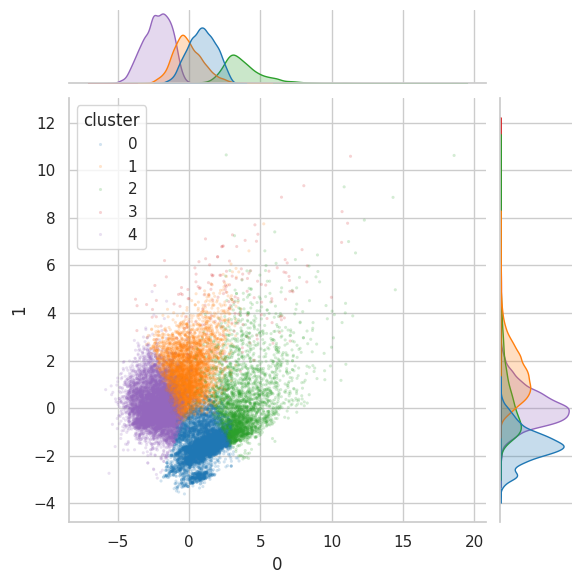

In [29]:
kmeans.n_clusters = 5
cluster_df = (kc_pca @ pca15.components_.T).copy()
# kmeans.fit(kc_pca) # clusters the same as transformed df
kmeans.fit(cluster_df)
cluster_df['cluster'] = kmeans.labels_
sns.set(rc={"figure.figsize":(7,7)})
sns.set_style('whitegrid')
sns.jointplot(cluster_df, x=0, y=1, hue='cluster', palette='tab10', s=5, lw=0, alpha=0.2)

In [30]:
pca15.explained_variance_

array([5.35974773e+00, 2.22750834e+00, 1.67494934e+00, 1.27441504e+00,
       9.38052055e-01, 7.40865675e-01, 6.68206096e-01, 5.54921579e-01,
       4.77004891e-01, 2.86492433e-01, 2.60501385e-01, 2.41940555e-01,
       2.09207207e-01, 8.68817223e-02, 1.86481784e-17])

In [31]:
pca15.explained_variance_ratio_
# sums up to 1, obtained from each expl variance over sum of expl variances

array([3.57299983e-01, 1.48493685e-01, 1.11658123e-01, 8.49570716e-02,
       6.25339102e-02, 4.93887598e-02, 4.45450119e-02, 3.69930603e-02,
       3.17988547e-02, 1.90986118e-02, 1.73659555e-02, 1.61286241e-02,
       1.39465018e-02, 5.79184683e-03, 1.24315437e-18])

In [32]:
pca15.singular_values_.round(5) # srt(eigenvalues * n_samples)

array([340.34522, 219.41037, 190.26036, 165.95981, 142.38392, 126.53691,
       120.17184, 109.5124 , 101.53339,  78.68719,  75.03303,  72.31058,
        67.24125,  43.33229,   0.     ])

In [33]:
pd.Series((eigenvalues[:14] * 21612) ** 0.5).sort_values(ascending=False).values

array([340.34521889, 219.41036966, 190.26036167, 165.95980792,
       142.38392118, 126.53690755, 120.17183588, 109.51239735,
       101.53339202,  78.6871937 ,  75.03303227,  72.3105752 ,
        67.24125339,  43.33229492])

In [34]:
pca15.mean_ # just the mean of each variable in the original matrix

array([-5.26011371e-17,  2.41965231e-16, -1.47283184e-16,  1.92520162e-15,
        8.41618194e-16,  3.28757107e-18,  1.31502843e-18, -2.47225345e-16,
        2.36705117e-16, -3.34017221e-16, -1.31502843e-18,  3.57687733e-16,
       -3.81358244e-17,  1.51228269e-16,  2.63005686e-18])

In [35]:
PCA(3).fit(kc_pca).noise_variance_ # average residual variance of disconsidered components

np.float64(0.4782073864907965)

In [36]:
pca15.explained_variance_[3:].mean()

np.float64(0.4782073864907965)

In [37]:
pca15.score(kc_pca) # log-likelihood

0.46794540183936767

In [38]:
pca15.score_samples(kc_pca) # log-likelihood per sample

array([ 5.7497705 , -0.56400686, -2.00401852, ...,  1.85133431,
        4.87088549,  1.89442109], shape=(21613,))

In [39]:
pca15.score_samples(kc_pca).sum() / 21613.0 
# joint likelihood is product, joint log likelihood is sum

np.float64(0.46794540183936767)